# Лабораторная работа №4
## Задание
Перевести текст в Google Translate и Яндекс.Переводчике

## Решение
### Исходное изображение


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


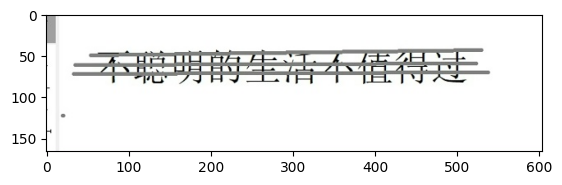

In [30]:
import cv2
from matplotlib import pyplot as plt

image_path = '/content/drive/MyDrive/Colab Notebooks/ЦОИ отчеты/l4pic.jpg'
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

### Пороговая фильтрация

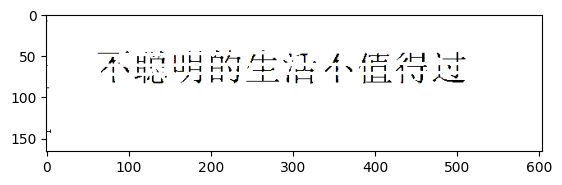

In [42]:
# порог яркости
threshold = 110
ret1, filtered_img = cv2.threshold(img_rgb, threshold, 255, cv2.THRESH_BINARY)

plt.imshow(filtered_img)

### Ещё несколько вариантов фильтрации

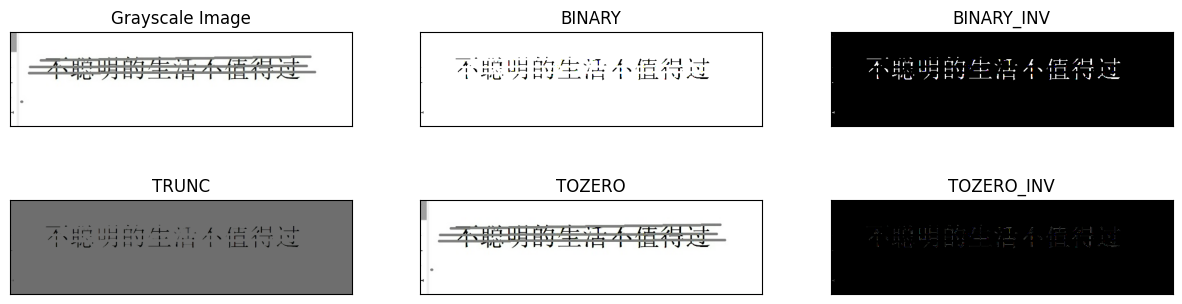

In [32]:
import numpy as np
threshold = 110
image = img_rgb

ret, res1 = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
ret, res2 = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY_INV)
ret, res3 = cv2.threshold(image, threshold, 255, cv2.THRESH_TRUNC)
ret, res4 = cv2.threshold(image, threshold, 255, cv2.THRESH_TOZERO)
ret, res5 = cv2.threshold(image, threshold, 255, cv2.THRESH_TOZERO_INV)
titles = ['Grayscale Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [image, res1, res2, res3, res4, res5]
plt.figure(figsize=(15, 4))
for i in np.arange(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.show()

Результат бинарной фильтрации уже выглядит неплохо, но хочется узнать насколько далеко оптимальный порог от выбранного вручную

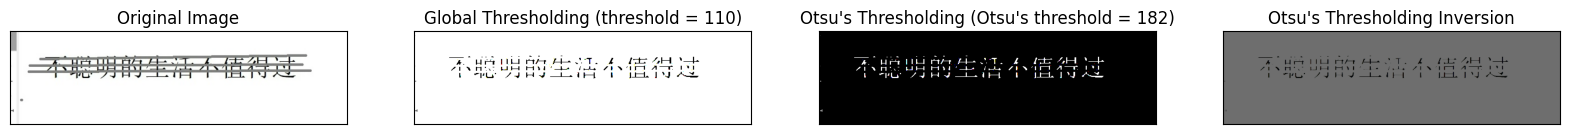

In [40]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
otsu_treshhold, res_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
res_inv = cv2.bitwise_not(res_otsu)
titles = ['Original Image', 'Global Thresholding (threshold = 110)',
          "Otsu's Thresholding (Otsu's threshold = %d)" % otsu_treshhold, "Otsu's Thresholding Inversion"]
images2 = [img_rgb, res1, res_otsu, res_inv]

plt.figure(figsize=(20, 5))
for i in np.arange(len(images2)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.show()

## Перевод от Google
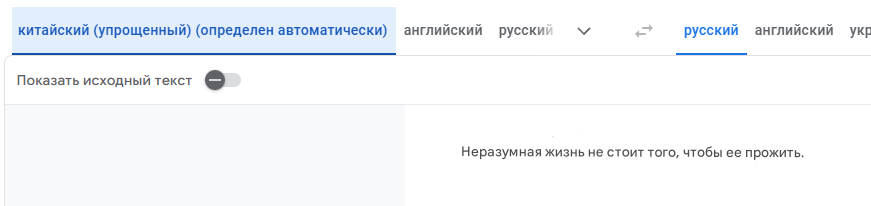

## Перевод от Яндекса
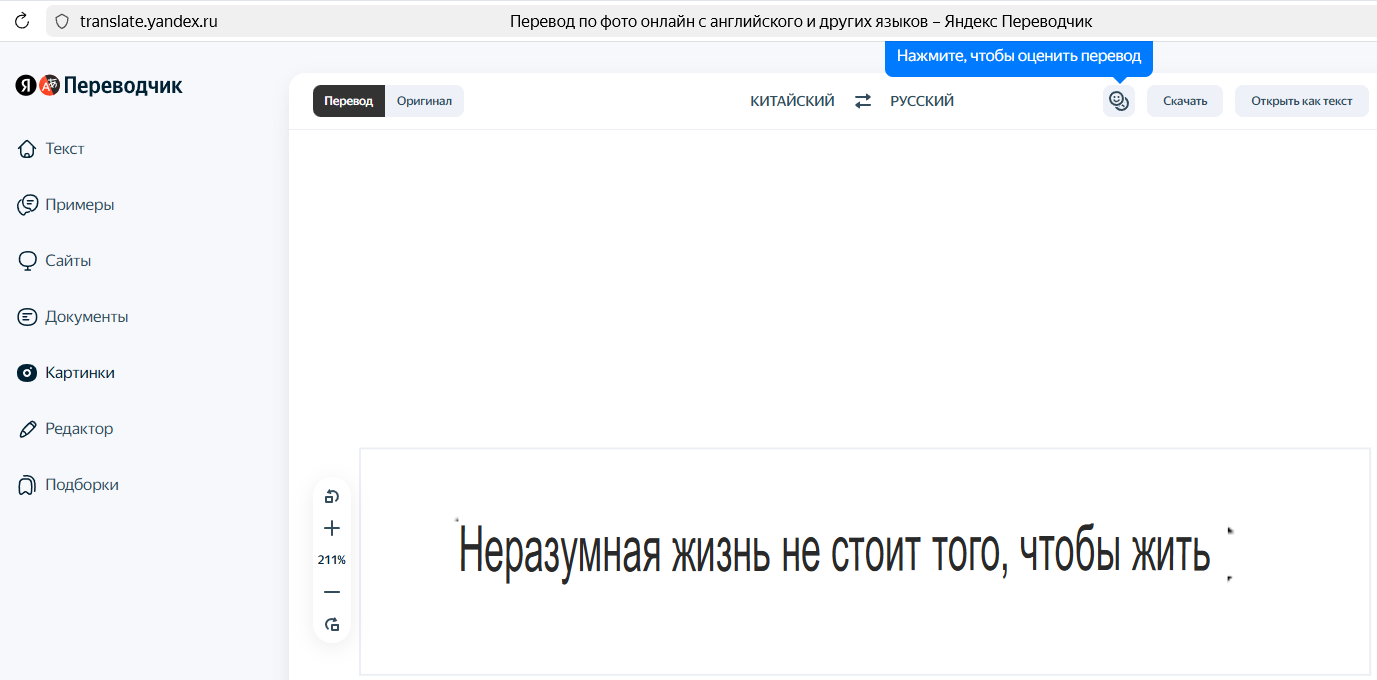